In [6]:
#--- Install dependencies ---
!pip install rclone torch torchvision matplotlib scikit-learn tqdm pillow


In [9]:
!curl https://rclone.org/install.sh | sudo bash

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0   7336      0 --:--:-- --:--:-- --:--:--  7339

The latest version of rclone rclone v1.73.2 is already installed.



In [10]:
!rclone listremotes

2026/03/07 00:13:31 NOTICE: Config file "/root/.config/rclone/rclone.conf" not found - using defaults


In [12]:
!wget "https://www.dropbox.com/scl/fi/q1ajcaxuzhru7z2ml4arh/LC25000.zip?rlkey=occoyixgx643aww35yoamdlqg&st=w5bxlp2y&dl=1" -O /content/LC25000.zip
!unzip -q /content/LC25000.zip -d /content/LC25000
!ls /content/LC25000/lung_colon_image_set/

--2026-03-07 00:48:36--  https://www.dropbox.com/scl/fi/q1ajcaxuzhru7z2ml4arh/LC25000.zip?rlkey=occoyixgx643aww35yoamdlqg&st=w5bxlp2y&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc731493d84b2f41538bfb9db28d.dl.dropboxusercontent.com/cd/0/inline/C8Jyqv1YdX4wO2tF32yA9cKFod_xylFNMDAHNDK0Q3-5yE5lPIxRSaMXNIa9GogTDmNgs1M-AiOXWBIrXtAXQi1SqauIZCZibXEC6cQ3KzWsfFWz_KCIhz2kMEbSAt6ftEvlGG2YVAdwO34PmOSvGv_b/file?dl=1# [following]
--2026-03-07 00:48:37--  https://uc731493d84b2f41538bfb9db28d.dl.dropboxusercontent.com/cd/0/inline/C8Jyqv1YdX4wO2tF32yA9cKFod_xylFNMDAHNDK0Q3-5yE5lPIxRSaMXNIa9GogTDmNgs1M-AiOXWBIrXtAXQi1SqauIZCZibXEC6cQ3KzWsfFWz_KCIhz2kMEbSAt6ftEvlGG2YVAdwO34PmOSvGv_b/file?dl=1
Resolving uc731493d84b2f41538bfb9db28d.dl.dropboxusercontent.com (uc731493d84b2f41538bfb9db28d.dl.dropboxusercontent

In [13]:
!unzip -q /content/LC25000.zip -d /content/LC25000
!ls /content/LC25000/

replace /content/LC25000/content/LC25000_complete/lung_colon_image_set/colon_image_sets/colon_aca/colonca809.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
content


In [14]:
!ls /content/LC25000/content/LC25000_complete/lung_colon_image_set/

colon_image_sets  lung_image_sets


In [15]:
!ls /content/LC25000/content/LC25000_complete/lung_colon_image_set/lung_image_sets/

lung_aca  lung_n  lung_scc


In [16]:
!ls /content/LC25000/content/LC25000_complete/lung_colon_image_set/lung_image_sets/lung_aca/ | head -5
!find /content/LC25000/content/LC25000_complete/lung_colon_image_set/lung_image_sets/ -type f | wc -l

lungaca1000.jpeg
lungaca1001.jpeg
lungaca1002.jpeg
lungaca1003.jpeg
lungaca1004.jpeg
15000


In [18]:
# IMPORTS
import os
import glob
import random
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import json
import logging
from datetime import datetime


# CONFIGURATION


class Config:
    """Central configuration — adjust paths and hyperparameters here."""

    # --- Paths ---
    DATA_ROOT = "/content/LC25000/content/LC25000_complete/lung_colon_image_set/lung_image_sets"
    FEATURE_CACHE_DIR = "/content/features_cache"
    CHECKPOINT_DIR = "/content/checkpoints"
    RESULTS_DIR = "/content/results"

    # --- Classes (NSCLC subtyping: lung only) ---
    # 0 = lung_aca (LUAD), 1 = lung_scc (LUSC), 2 = lung_n (Normal)
    CLASS_MAP = {
        "lung_aca": 0,   # Adenocarcinoma
        "lung_scc": 1,   # Squamous Cell Carcinoma
        "lung_n":   2,   # Normal
    }
    CLASS_NAMES = ["LUAD", "LUSC", "Normal"]
    N_CLASSES = 3

    # --- Feature extraction ---
    BACKBONE = "resnet50"
    FEATURE_DIM = 2048       # ResNet-50 output dim (before FC)
    PATCH_SIZE = 768         # LC25000 native patch size
    INPUT_SIZE = 224         # ResNet input size
    BATCH_SIZE_EXTRACT = 64  # Batch size for feature extraction

    # --- Bag construction ---
    BAG_SIZE_MIN = 30
    BAG_SIZE_MAX = 100
    N_BAGS_PER_CLASS = 150   # Total bags = 150 * 3 = 450
    SEED = 42

    # --- ABMIL hyperparameters ---
    HIDDEN_DIM = 128         # Attention network hidden dim
    DROPOUT = 0.25
    LR = 1e-4
    WEIGHT_DECAY = 1e-5
    N_EPOCHS = 50
    PATIENCE = 10            # Early stopping patience
    BAG_BATCH_SIZE = 1       # MIL typically uses 1 bag per step

    # --- Device ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def setup_directories(cfg: Config):
    """Create output directories."""
    for d in [cfg.FEATURE_CACHE_DIR, cfg.CHECKPOINT_DIR, cfg.RESULTS_DIR]:
        os.makedirs(d, exist_ok=True)

def set_seed(seed: int):
    """Reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

COMP 499 — ABMIL Pipeline on LC25000
Device: cpu
Classes: ['LUAD', 'LUSC', 'Normal']

[Phase 2] Feature Extraction
[Feature Extraction] Computing features with frozen ResNet-50...
  lung_aca: 5000 patches found
  lung_scc: 5000 patches found
  lung_n: 5000 patches found

  Processing lung_aca (5000 patches)...


  lung_aca: 100%|██████████| 79/79 [26:34<00:00, 20.19s/it]


  lung_aca features shape: (5000, 2048)

  Processing lung_scc (5000 patches)...


  lung_scc: 100%|██████████| 79/79 [25:58<00:00, 19.73s/it]


  lung_scc features shape: (5000, 2048)

  Processing lung_n (5000 patches)...


  lung_n: 100%|██████████| 79/79 [26:12<00:00, 19.91s/it]


  lung_n features shape: (5000, 2048)

[Feature Extraction] Cached to /content/features_cache/lung_features.npz

[Phase 3] Bag Construction
  lung_aca: 4000 train / 1000 val patches
  lung_scc: 4000 train / 1000 val patches
  lung_n: 4000 train / 1000 val patches

  Total bags — Train: 450, Val: 450

[Phase 4] ABMIL Model
  Parameters: 1,312,644

[Sanity Check] Overfitting on 5 bags...
  After 10 epochs on 5 bags: Loss=0.0378, Acc=1.0000
  (Should be near 0.0 loss and 1.0 acc if model can learn)

[Phase 5] Full Training

Training ABMIL — 50 epochs, device: cpu

Epoch   1/50 | Train Loss: 0.2804  Acc: 0.9422 | Val Loss: 0.0022  Acc: 1.0000
  -> Saved best model (val_loss=0.0022)
Epoch   2/50 | Train Loss: 0.0010  Acc: 1.0000 | Val Loss: 0.0003  Acc: 1.0000
  -> Saved best model (val_loss=0.0003)
Epoch   3/50 | Train Loss: 0.0003  Acc: 1.0000 | Val Loss: 0.0001  Acc: 1.0000
  -> Saved best model (val_loss=0.0001)
Epoch   4/50 | Train Loss: 0.0001  Acc: 1.0000 | Val Loss: 0.0000  Acc: 1.0

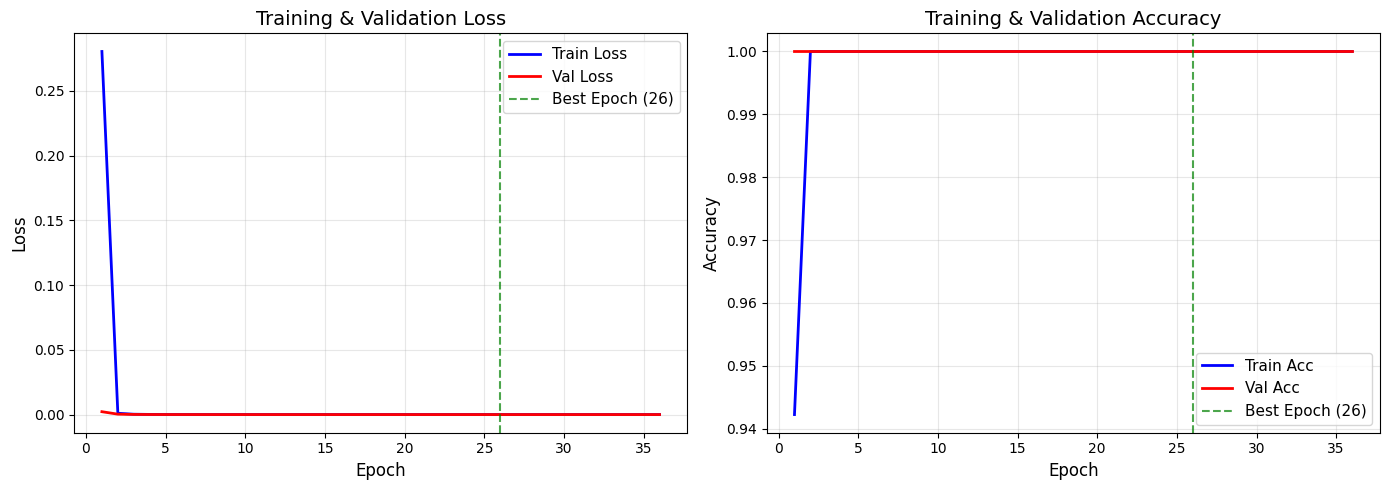

  Saved: /content/results/training_curves.png


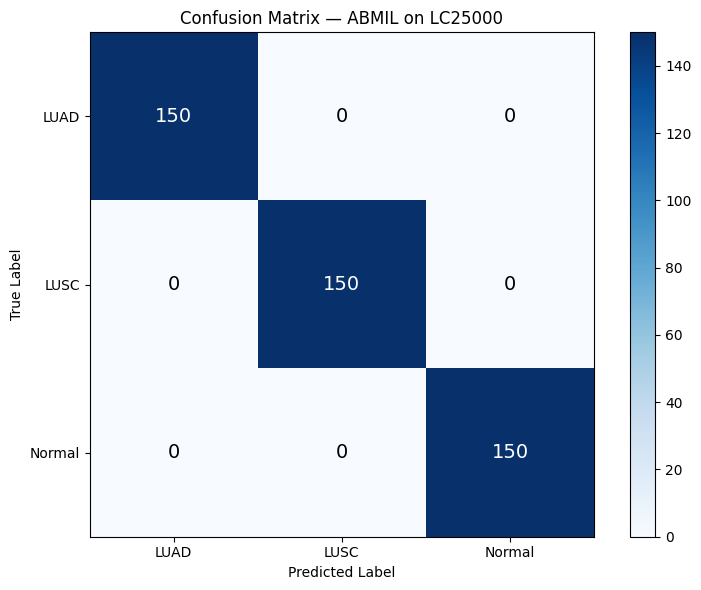

  Saved: /content/results/confusion_matrix.png

Classification Report — ABMIL on LC25000
              precision    recall  f1-score   support

        LUAD     1.0000    1.0000    1.0000       150
        LUSC     1.0000    1.0000    1.0000       150
      Normal     1.0000    1.0000    1.0000       150

    accuracy                         1.0000       450
   macro avg     1.0000    1.0000    1.0000       450
weighted avg     1.0000    1.0000    1.0000       450


Overall Accuracy: 1.0000
Macro F1-Score:   1.0000

Bag 247 (LUSC) — Top-5 attention: [(14, 0.04470000043511391), (19, 0.03660000115633011), (46, 0.03629999980330467), (58, 0.031099999323487282), (26, 0.030500000342726707)]

Bag 176 (LUSC) — Top-5 attention: [(25, 0.052400000393390656), (13, 0.04969999939203262), (28, 0.04610000178217888), (42, 0.04430000111460686), (8, 0.0430000014603138)]

Bag 170 (LUSC) — Top-5 attention: [(38, 0.03290000185370445), (67, 0.030400000512599945), (30, 0.030300000682473183), (10, 0.0285000000

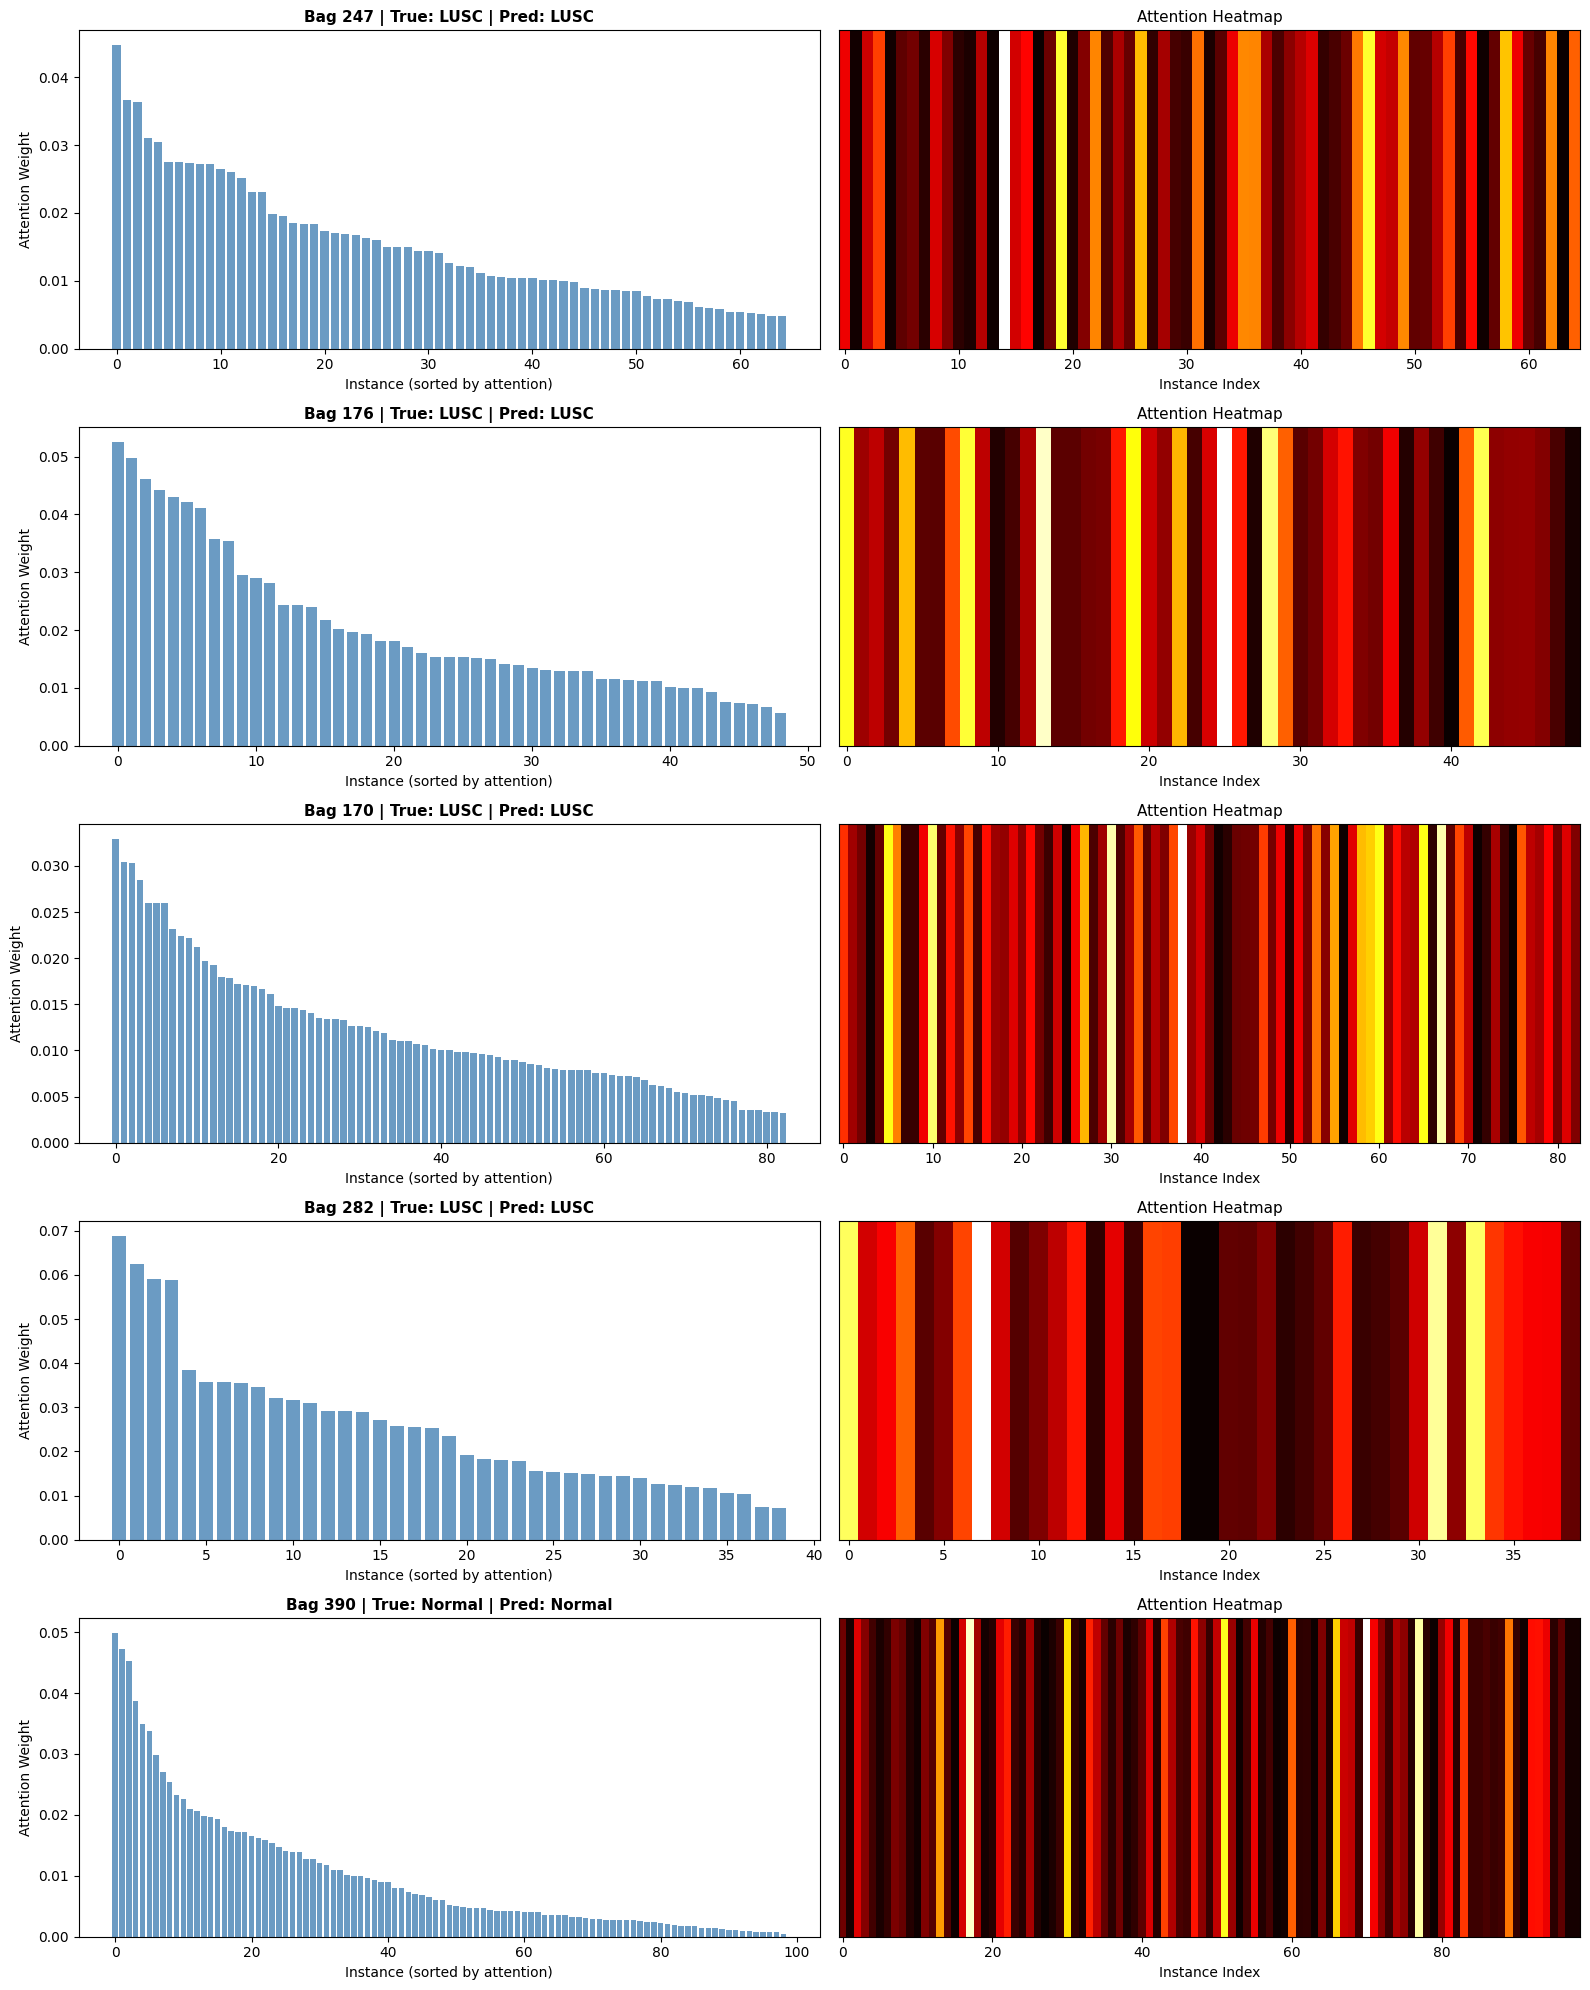

  Saved: /content/results/attention_visualizations.png

Pipeline complete!
Results saved to: /content/results
Best model saved to: /content/checkpoints


In [20]:
# PHASE 2: FEATURE EXTRACTION

class PatchFeatureExtractor:
    """
    Extracts features from LC25000 patches using a frozen ResNet-50 backbone.

    Removes the final classification layer, yielding 2048-dim feature vectors.
    Features are cached to disk as .npy files to avoid recomputation.
    """

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.device = cfg.DEVICE

        # Load pretrained ResNet-50, remove classifier head
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.model = nn.Sequential(*list(backbone.children())[:-1])  # -> (B, 2048, 1, 1)
        self.model.eval().to(self.device)

        # Standard ImageNet preprocessing
        self.transform = transforms.Compose([
            transforms.Resize((cfg.INPUT_SIZE, cfg.INPUT_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

    def _load_patch_paths(self) -> Dict[str, List[str]]:
        """Collect all patch file paths per lung class."""
        patch_paths = {}
        for class_name in self.cfg.CLASS_MAP.keys():
            folder = os.path.join(self.cfg.DATA_ROOT, class_name)
            paths = sorted(glob.glob(os.path.join(folder, "*.jpeg")))
            if not paths:
                paths = sorted(glob.glob(os.path.join(folder, "*.png")))
            if not paths:
                paths = sorted(glob.glob(os.path.join(folder, "*")))
            patch_paths[class_name] = paths
            print(f"  {class_name}: {len(paths)} patches found")
        return patch_paths

    @torch.no_grad()
    def extract_features(self) -> Dict[str, np.ndarray]:
        """
        Extract and cache features for all lung patches.

        Returns:
            dict mapping class_name -> np.ndarray of shape (N_patches, 2048)
        """
        cache_file = os.path.join(self.cfg.FEATURE_CACHE_DIR, "lung_features.npz")

        # Check cache
        if os.path.exists(cache_file):
            print("[Feature Extraction] Loading cached features...")
            data = np.load(cache_file)
            features = {key: data[key] for key in data.files}
            for k, v in features.items():
                print(f"  {k}: {v.shape}")
            return features

        print("[Feature Extraction] Computing features with frozen ResNet-50...")
        patch_paths = self._load_patch_paths()
        features = {}

        for class_name, paths in patch_paths.items():
            print(f"\n  Processing {class_name} ({len(paths)} patches)...")
            class_features = []

            # Batch processing
            for i in tqdm(range(0, len(paths), self.cfg.BATCH_SIZE_EXTRACT),
                          desc=f"  {class_name}"):
                batch_paths = paths[i : i + self.cfg.BATCH_SIZE_EXTRACT]
                batch_tensors = []

                for p in batch_paths:
                    img = Image.open(p).convert("RGB")
                    batch_tensors.append(self.transform(img))

                batch = torch.stack(batch_tensors).to(self.device)
                feats = self.model(batch).squeeze(-1).squeeze(-1)  # (B, 2048)
                class_features.append(feats.cpu().numpy())

            features[class_name] = np.concatenate(class_features, axis=0)
            print(f"  {class_name} features shape: {features[class_name].shape}")

        # Cache to disk
        np.savez_compressed(cache_file, **features)
        print(f"\n[Feature Extraction] Cached to {cache_file}")

        return features


# PHASE 3: BAG CONSTRUCTION

class MILBagDataset(Dataset):
    """
    Constructs simulated MIL bags from LC25000 patch features.

    Strategy:
      - For each class, sample N_BAGS_PER_CLASS bags.
      - Each bag contains BAG_SIZE_MIN to BAG_SIZE_MAX randomly sampled
        patch features from that class.
      - Bag-level label = class label.

    This simulates the MIL paradigm where a WSI (bag) contains many
    patches (instances) and only the slide-level label is known.
    """

    def __init__(
        self,
        features: Dict[str, np.ndarray],
        indices: Dict[str, np.ndarray],
        cfg: Config,
    ):
        """
        Args:
            features: dict of class_name -> (N, D) feature arrays
            indices:  dict of class_name -> array of patch indices to use
                      (for train/val splitting at the patch level)
            cfg:      Config object
        """
        self.cfg = cfg
        self.bags = []
        self.labels = []

        for class_name, label in cfg.CLASS_MAP.items():
            class_feats = features[class_name][indices[class_name]]

            for _ in range(cfg.N_BAGS_PER_CLASS):
                bag_size = random.randint(cfg.BAG_SIZE_MIN, cfg.BAG_SIZE_MAX)
                # Sample with replacement if needed
                idx = np.random.choice(len(class_feats), size=bag_size, replace=True)
                bag = class_feats[idx]
                self.bags.append(torch.FloatTensor(bag))
                self.labels.append(label)

    def __len__(self) -> int:
        return len(self.bags)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        return self.bags[idx], self.labels[idx]


def collate_mil(batch):
    """
    Custom collate for variable-size bags.

    Since bag sizes vary, we cannot stack them into a single tensor.
    Returns a list of bag tensors and a label tensor.
    """
    bags, labels = zip(*batch)
    labels = torch.LongTensor(labels)
    return bags, labels


def create_datasets(
    features: Dict[str, np.ndarray],
    cfg: Config,
    test_size: float = 0.2,
) -> Tuple[MILBagDataset, MILBagDataset]:
    """
    Split patches 80/20 per class, then construct bags from each split.

    This ensures train and validation bags contain different patches,
    preventing data leakage.
    """
    train_indices = {}
    val_indices = {}

    for class_name in cfg.CLASS_MAP.keys():
        n_patches = len(features[class_name])
        all_idx = np.arange(n_patches)
        tr_idx, va_idx = train_test_split(
            all_idx, test_size=test_size, random_state=cfg.SEED
        )
        train_indices[class_name] = tr_idx
        val_indices[class_name] = va_idx
        print(f"  {class_name}: {len(tr_idx)} train / {len(va_idx)} val patches")

    train_dataset = MILBagDataset(features, train_indices, cfg)
    val_dataset = MILBagDataset(features, val_indices, cfg)

    print(f"\n  Total bags — Train: {len(train_dataset)}, Val: {len(val_dataset)}")
    return train_dataset, val_dataset


# PHASE 4: ABMIL MODEL (Ilse et al., ICML 2018)

class GatedAttention(nn.Module):
    """
    Gated Attention Mechanism for MIL (Ilse et al., 2018).

    Computes attention weights over instances in a bag using a
    gated tanh-sigmoid mechanism:

        a_i = w^T (tanh(V h_i) ⊙ sigmoid(U h_i))
        α   = softmax(a)

    This is the gated variant which empirically outperforms the
    non-gated version (tanh only) in the original paper.
    """

    def __init__(self, feature_dim: int, hidden_dim: int, dropout: float = 0.25):
        super().__init__()

        self.attention_V = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh(),
        )
        self.attention_U = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Sigmoid(),
        )
        self.attention_w = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            h: (N_instances, feature_dim) — patch features in a bag

        Returns:
            z:     (feature_dim,) — bag-level representation
            alpha: (N_instances,) — attention weights (sum to 1)
        """
        # Gated attention scores
        a_V = self.attention_V(h)       # (N, hidden_dim)
        a_U = self.attention_U(h)       # (N, hidden_dim)
        a = self.attention_w(self.dropout(a_V * a_U))  # (N, 1)

        # Softmax over instances
        alpha = F.softmax(a, dim=0)     # (N, 1)

        # Weighted sum -> bag representation
        z = torch.sum(alpha * h, dim=0) # (feature_dim,)

        return z, alpha.squeeze(-1)


class ABMIL(nn.Module):
    """
    Attention-Based Deep Multiple Instance Learning (ABMIL).

    Architecture:
      1. (Optional) Feature projection: reduce dim if needed
      2. Gated attention mechanism -> bag representation z
      3. Classifier head -> class logits

    Returns both logits and attention weights for interpretability analysis.
    """

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg

        # Optional feature projection (useful if switching to CONCH 512-d later)
        self.feature_proj = nn.Sequential(
            nn.Linear(cfg.FEATURE_DIM, 512),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
        )

        # Gated attention
        self.attention = GatedAttention(
            feature_dim=512,
            hidden_dim=cfg.HIDDEN_DIM,
            dropout=cfg.DROPOUT,
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(256, cfg.N_CLASSES),
        )

    def forward(
        self, bag: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            bag: (N_instances, feature_dim) — one bag of patch features

        Returns:
            logits:  (N_classes,) — class predictions
            alpha:   (N_instances,) — attention weights per patch
        """
        # Project features
        h = self.feature_proj(bag)      # (N, 512)

        # Attention pooling
        z, alpha = self.attention(h)    # z: (512,), alpha: (N,)

        # Classification
        logits = self.classifier(z)     # (N_classes,)

        return logits, alpha


# PHASE 5: TRAINING & EVALUATION

class Trainer:
    """Handles training loop, validation, early stopping, and logging."""

    def __init__(self, model: ABMIL, cfg: Config):
        self.model = model.to(cfg.DEVICE)
        self.cfg = cfg
        self.device = cfg.DEVICE

        self.optimizer = torch.optim.Adam(
            model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=cfg.N_EPOCHS, eta_min=1e-6
        )
        self.criterion = nn.CrossEntropyLoss()

        # Tracking
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.best_val_loss = float("inf")
        self.best_epoch = 0
        self.patience_counter = 0

    def train_epoch(self, dataloader: DataLoader) -> Tuple[float, float]:
        """Single training epoch."""
        self.model.train()
        total_loss = 0.0
        all_preds, all_labels = [], []

        for bags, labels in dataloader:
            labels = labels.to(self.device)

            # MIL: iterate over bags (batch size is typically 1)
            for i in range(len(bags)):
                bag = bags[i].to(self.device)
                label = labels[i].unsqueeze(0)

                logits, _ = self.model(bag)
                loss = self.criterion(logits.unsqueeze(0), label)

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()

                total_loss += loss.item()
                all_preds.append(logits.argmax().item())
                all_labels.append(label.item())

        avg_loss = total_loss / len(all_preds)
        accuracy = accuracy_score(all_labels, all_preds)
        return avg_loss, accuracy

    @torch.no_grad()
    def validate(self, dataloader: DataLoader) -> Tuple[float, float, list, list]:
        """Validation pass."""
        self.model.eval()
        total_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []

        for bags, labels in dataloader:
            labels = labels.to(self.device)

            for i in range(len(bags)):
                bag = bags[i].to(self.device)
                label = labels[i].unsqueeze(0)

                logits, _ = self.model(bag)
                loss = self.criterion(logits.unsqueeze(0), label)

                total_loss += loss.item()
                probs = F.softmax(logits, dim=0)
                all_preds.append(logits.argmax().item())
                all_labels.append(label.item())
                all_probs.append(probs.cpu().numpy())

        avg_loss = total_loss / len(all_preds)
        accuracy = accuracy_score(all_labels, all_preds)
        return avg_loss, accuracy, all_preds, all_labels

    def fit(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
    ) -> dict:
        """Full training loop with early stopping."""

        print(f"\n{'='*60}")
        print(f"Training ABMIL — {self.cfg.N_EPOCHS} epochs, device: {self.device}")
        print(f"{'='*60}\n")

        for epoch in range(1, self.cfg.N_EPOCHS + 1):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)

            # Validate
            val_loss, val_acc, val_preds, val_labels = self.validate(val_loader)
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)

            self.scheduler.step()

            # Logging
            print(
                f"Epoch {epoch:3d}/{self.cfg.N_EPOCHS} | "
                f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
            )

            # Early stopping check
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_epoch = epoch
                self.patience_counter = 0
                # Save best model
                ckpt_path = os.path.join(
                    self.cfg.CHECKPOINT_DIR, "best_abmil.pth"
                )
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": self.optimizer.state_dict(),
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                }, ckpt_path)
                print(f"  -> Saved best model (val_loss={val_loss:.4f})")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.cfg.PATIENCE:
                    print(f"\nEarly stopping at epoch {epoch} "
                          f"(best epoch: {self.best_epoch})")
                    break

        # Load best model for final evaluation
        ckpt = torch.load(
            os.path.join(self.cfg.CHECKPOINT_DIR, "best_abmil.pth"),
            map_location=self.device,
        )
        self.model.load_state_dict(ckpt["model_state_dict"])

        return {
            "best_epoch": self.best_epoch,
            "best_val_loss": self.best_val_loss,
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "train_accs": self.train_accs,
            "val_accs": self.val_accs,
        }


# RESULTS GENERATION & VISUALIZATION

class ResultsGenerator:
    """Generates all figures and metrics for the progress report."""

    def __init__(self, model: ABMIL, cfg: Config):
        self.model = model.to(cfg.DEVICE)
        self.cfg = cfg
        self.device = cfg.DEVICE

    def plot_training_curves(self, history: dict, save_path: str):
        """Plot training and validation loss/accuracy curves."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        epochs = range(1, len(history["train_losses"]) + 1)

        # Loss
        ax1.plot(epochs, history["train_losses"], "b-", label="Train Loss", linewidth=2)
        ax1.plot(epochs, history["val_losses"], "r-", label="Val Loss", linewidth=2)
        ax1.axvline(history["best_epoch"], color="green", linestyle="--",
                     alpha=0.7, label=f"Best Epoch ({history['best_epoch']})")
        ax1.set_xlabel("Epoch", fontsize=12)
        ax1.set_ylabel("Loss", fontsize=12)
        ax1.set_title("Training & Validation Loss", fontsize=14)
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)

        # Accuracy
        ax2.plot(epochs, history["train_accs"], "b-", label="Train Acc", linewidth=2)
        ax2.plot(epochs, history["val_accs"], "r-", label="Val Acc", linewidth=2)
        ax2.axvline(history["best_epoch"], color="green", linestyle="--",
                     alpha=0.7, label=f"Best Epoch ({history['best_epoch']})")
        ax2.set_xlabel("Epoch", fontsize=12)
        ax2.set_ylabel("Accuracy", fontsize=12)
        ax2.set_title("Training & Validation Accuracy", fontsize=14)
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {save_path}")

    def plot_confusion_matrix(self, preds, labels, save_path: str):
        """Plot confusion matrix for validation set."""
        cm = confusion_matrix(labels, preds)
        fig, ax = plt.subplots(figsize=(8, 6))

        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
        ax.figure.colorbar(im, ax=ax)

        classes = self.cfg.CLASS_NAMES
        ax.set(
            xticks=np.arange(cm.shape[1]),
            yticks=np.arange(cm.shape[0]),
            xticklabels=classes,
            yticklabels=classes,
            ylabel="True Label",
            xlabel="Predicted Label",
            title="Confusion Matrix — ABMIL on LC25000",
        )

        # Annotate cells
        thresh = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, f"{cm[i, j]}",
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black",
                        fontsize=14)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {save_path}")

    @torch.no_grad()
    def visualize_attention(
        self,
        dataset: MILBagDataset,
        n_samples: int = 5,
        save_path: str = None,
    ):
        """
        Visualize attention weight distributions for sample bags.

        Shows which instances (patches) the model attends to most,
        directly relevant to the project's core question about
        attention-attribution faithfulness.
        """
        self.model.eval()
        fig, axes = plt.subplots(n_samples, 2, figsize=(16, 4 * n_samples))

        sample_indices = random.sample(range(len(dataset)), n_samples)

        for row, idx in enumerate(sample_indices):
            bag, label = dataset[idx]
            bag = bag.to(self.device)

            logits, alpha = self.model(bag)
            pred = logits.argmax().item()
            alpha_np = alpha.cpu().numpy()

            # Left: Attention weight bar plot
            ax_bar = axes[row, 0]
            sorted_idx = np.argsort(alpha_np)[::-1]
            ax_bar.bar(range(len(alpha_np)), alpha_np[sorted_idx],
                       color="steelblue", alpha=0.8)
            ax_bar.set_xlabel("Instance (sorted by attention)", fontsize=10)
            ax_bar.set_ylabel("Attention Weight", fontsize=10)
            ax_bar.set_title(
                f"Bag {idx} | True: {self.cfg.CLASS_NAMES[label]} | "
                f"Pred: {self.cfg.CLASS_NAMES[pred]}",
                fontsize=11, fontweight="bold"
            )

            # Right: Attention heatmap (1D for now; 2D for real WSIs later)
            ax_heat = axes[row, 1]
            ax_heat.imshow(alpha_np.reshape(1, -1), aspect="auto",
                           cmap="hot", interpolation="nearest")
            ax_heat.set_xlabel("Instance Index", fontsize=10)
            ax_heat.set_yticks([])
            ax_heat.set_title("Attention Heatmap", fontsize=11)

            # Print top-5 attended instances
            top5 = sorted_idx[:5]
            top5_weights = alpha_np[top5]
            print(f"\nBag {idx} ({self.cfg.CLASS_NAMES[label]}) — "
                  f"Top-5 attention: {list(zip(top5.tolist(), top5_weights.round(4).tolist()))}")

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {save_path}")

    def generate_classification_report(
        self, preds, labels, save_path: str
    ):
        """Generate and save a full classification report."""
        report = classification_report(
            labels, preds,
            target_names=self.cfg.CLASS_NAMES,
            digits=4,
        )
        print("\n" + "=" * 60)
        print("Classification Report — ABMIL on LC25000")
        print("=" * 60)
        print(report)

        with open(save_path, "w") as f:
            f.write("Classification Report — ABMIL on LC25000\n")
            f.write("=" * 60 + "\n")
            f.write(report)
            f.write("\n\nGenerated: " + datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

        f1 = f1_score(labels, preds, average="macro")
        acc = accuracy_score(labels, preds)

        print(f"\nOverall Accuracy: {acc:.4f}")
        print(f"Macro F1-Score:   {f1:.4f}")
        return {"accuracy": acc, "f1_macro": f1}


# MAIN EXECUTION

def main():
    """
    Full pipeline execution:
      1. Setup
      2. Extract features (or load from cache)
      3. Construct MIL bags
      4. Train ABMIL
      5. Generate results
    """

    # --- Setup ---
    cfg = Config()
    set_seed(cfg.SEED)
    setup_directories(cfg)


    print("COMP 499 — ABMIL Pipeline on LC25000")
    print(f"Device: {cfg.DEVICE}")
    print(f"Classes: {cfg.CLASS_NAMES}")
    print("=" * 60)

    # --- Phase 2: Feature Extraction ---
    print("\n[Phase 2] Feature Extraction")
    extractor = PatchFeatureExtractor(cfg)
    features = extractor.extract_features()

    # --- Phase 3: Bag Construction ---
    print("\n[Phase 3] Bag Construction")
    train_dataset, val_dataset = create_datasets(features, cfg)

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg.BAG_BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_mil,
        num_workers=2,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.BAG_BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_mil,
        num_workers=2,
    )

    # --- Phase 4 & 5: Train ABMIL ---
    print("\n[Phase 4] ABMIL Model")
    model = ABMIL(cfg)
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

    trainer = Trainer(model, cfg)

    # Quick sanity check: overfit on 5 bags
    print("\n[Sanity Check] Overfitting on 5 bags...")
    tiny_dataset = torch.utils.data.Subset(train_dataset, range(5))
    tiny_loader = DataLoader(
        tiny_dataset, batch_size=1, shuffle=True, collate_fn=collate_mil
    )
    for _ in range(10):
        loss, acc = trainer.train_epoch(tiny_loader)
    print(f"  After 10 epochs on 5 bags: Loss={loss:.4f}, Acc={acc:.4f}")
    print("  (Should be near 0.0 loss and 1.0 acc if model can learn)")

    # Re-initialize for full training
    model = ABMIL(cfg)
    trainer = Trainer(model, cfg)

    print("\n[Phase 5] Full Training")
    history = trainer.fit(train_loader, val_loader)

    # --- Generate Results ---
    print("\n[Results] Generating figures and metrics...")
    results_gen = ResultsGenerator(model, cfg)

    # Training curves
    results_gen.plot_training_curves(
        history,
        save_path=os.path.join(cfg.RESULTS_DIR, "training_curves.png"),
    )

    # Final validation metrics
    _, _, val_preds, val_labels = trainer.validate(val_loader)

    # Confusion matrix
    results_gen.plot_confusion_matrix(
        val_preds, val_labels,
        save_path=os.path.join(cfg.RESULTS_DIR, "confusion_matrix.png"),
    )

    # Classification report
    metrics = results_gen.generate_classification_report(
        val_preds, val_labels,
        save_path=os.path.join(cfg.RESULTS_DIR, "classification_report.txt"),
    )

    # Attention visualizations
    results_gen.visualize_attention(
        val_dataset,
        n_samples=5,
        save_path=os.path.join(cfg.RESULTS_DIR, "attention_visualizations.png"),
    )

    # Save final summary
    summary = {
        "model": "ABMIL (Ilse et al., 2018)",
        "backbone": cfg.BACKBONE,
        "dataset": "LC25000 (lung subset)",
        "n_classes": cfg.N_CLASSES,
        "class_names": cfg.CLASS_NAMES,
        "n_bags_train": len(train_dataset),
        "n_bags_val": len(val_dataset),
        "bag_size_range": [cfg.BAG_SIZE_MIN, cfg.BAG_SIZE_MAX],
        "best_epoch": history["best_epoch"],
        "best_val_loss": history["best_val_loss"],
        "final_accuracy": metrics["accuracy"],
        "final_f1_macro": metrics["f1_macro"],
        "hyperparameters": {
            "lr": cfg.LR,
            "hidden_dim": cfg.HIDDEN_DIM,
            "dropout": cfg.DROPOUT,
            "n_epochs": cfg.N_EPOCHS,
            "patience": cfg.PATIENCE,
        },
    }

    with open(os.path.join(cfg.RESULTS_DIR, "experiment_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print("\n" + "=" * 60)
    print("Pipeline complete!")
    print(f"Results saved to: {cfg.RESULTS_DIR}")
    print(f"Best model saved to: {cfg.CHECKPOINT_DIR}")
    print("=" * 60)


if __name__ == "__main__":
    main()